### 1. Data Import and EDA

In [218]:
import warnings as w
w.filterwarnings('ignore')

import pandas as pd
movies=pd.read_csv('movies.csv',sep=',')
credits=pd.read_csv('credits.csv',sep=',')

print(movies.head())

      budget                                             genres  \
0  237000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
1  300000000  [{"id": 12, "name": "Adventure"}, {"id": 14, "...   
2  245000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
3  250000000  [{"id": 28, "name": "Action"}, {"id": 80, "nam...   
4  260000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   

                                       homepage      id  \
0                   http://www.avatarmovie.com/   19995   
1  http://disney.go.com/disneypictures/pirates/     285   
2   http://www.sonypictures.com/movies/spectre/  206647   
3            http://www.thedarkknightrises.com/   49026   
4          http://movies.disney.com/john-carter   49529   

                                            keywords original_language  \
0  [{"id": 1463, "name": "culture clash"}, {"id":...                en   
1  [{"id": 270, "name": "ocean"}, {"id": 726, "na...                en   
2  [{"id": 470, "nam

In [219]:
print(credits.tail())

      movie_id                      title  \
4798      9367                El Mariachi   
4799     72766                  Newlyweds   
4800    231617  Signed, Sealed, Delivered   
4801    126186           Shanghai Calling   
4802     25975          My Date with Drew   

                                                   cast  \
4798  [{"cast_id": 1, "character": "El Mariachi", "c...   
4799  [{"cast_id": 1, "character": "Buzzy", "credit_...   
4800  [{"cast_id": 8, "character": "Oliver O\u2019To...   
4801  [{"cast_id": 3, "character": "Sam", "credit_id...   
4802  [{"cast_id": 3, "character": "Herself", "credi...   

                                                   crew  
4798  [{"credit_id": "52fe44eec3a36847f80b280b", "de...  
4799  [{"credit_id": "52fe487dc3a368484e0fb013", "de...  
4800  [{"credit_id": "52fe4df3c3a36847f8275ecf", "de...  
4801  [{"credit_id": "52fe4ad9c3a368484e16a36b", "de...  
4802  [{"credit_id": "58ce021b9251415a390165d9", "de...  


In [220]:
movies.shape

(4803, 20)

In [221]:
credits.shape

(4803, 4)

In [222]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

In [223]:
credits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   movie_id  4803 non-null   int64 
 1   title     4803 non-null   object
 2   cast      4803 non-null   object
 3   crew      4803 non-null   object
dtypes: int64(1), object(3)
memory usage: 150.2+ KB


In [224]:
movies.describe(include='object')

,genres,homepage,keywords,original_language,original_title,overview,production_companies,production_countries,release_date,spoken_languages,status,tagline,title
count,4803,1712,4803,4803,4803,4800,4803,4803,4802,4803,4803,3959,4803
unique,1175,1691,4222,37,4801,4800,3697,469,3280,544,3,3944,4800
top,"[{""id"": 18, ""name"": ""Drama""}]",http://www.missionimpossible.com/,[],en,Out of the Blue,"In the 22nd century, a paraplegic Marine is di...",[],"[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2006-01-01,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,Based on a true story.,The Host
freq,370,4,412,4505,2,1,351,2977,10,3171,4795,3,2


In [225]:
credits.describe(include='object')

,title,cast,crew
count,4803,4803,4803
unique,4800,4761,4776
top,The Host,[],[]
freq,2,43,28


### Data Cleaning & Feature Engineering

In [226]:
movies.duplicated().sum()

np.int64(0)

In [227]:
credits.duplicated().sum()

np.int64(0)

In [228]:
movies['id'].unique().size

4803

In [229]:
credits['movie_id'].unique().size

4803

In [230]:
movies=movies.merge(credits,on=['title'])

In [231]:
movies.head(3)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,movie_id,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,285,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,206647,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."


In [232]:
corr=movies.corr(numeric_only=True)

<Axes: >

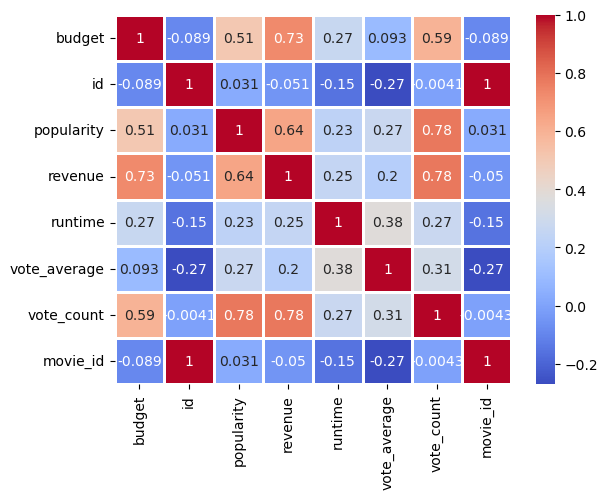

In [233]:
import seaborn as sns
sns.heatmap(corr, annot=True, cmap='coolwarm',linewidth=1)

**Since the "id" and 'movie_id' from the sources are duplicates/Multicollinearity, we will perform Omission**

In [234]:
movies=movies.drop('id',axis=1)
movies.shape

(4809, 22)

In [235]:
movies.isna().sum()

budget                     0
genres                     0
homepage                3096
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
movie_id                   0
cast                       0
crew                       0
dtype: int64

In [236]:
movies['homepage'].dtype

dtype('O')

**Since homepage is not KPI for this business issue and also >60% of the homepage data is missing , we can simply omit the column**

In [237]:
movies=movies.drop('homepage',axis=1)

In [238]:
movies['overview'].value_counts().sum()

np.int64(4806)

In [239]:
movies['overview']=movies['overview'].fillna('')

In [240]:
movies['release_date'].head()

0    2009-12-10
1    2007-05-19
2    2015-10-26
3    2012-07-16
4    2012-03-07
Name: release_date, dtype: object

In [241]:
movies['release_date']=movies['release_date'].fillna('')

In [242]:
movies['runtime'].tail()

4804     81.0
4805     85.0
4806    120.0
4807     98.0
4808     90.0
Name: runtime, dtype: float64

In [243]:
movies['runtime'].dtype

dtype('float64')

In [244]:
movies['runtime'].describe()

count    4807.000000
mean      106.882255
std        22.602535
min         0.000000
25%        94.000000
50%       103.000000
75%       118.000000
max       338.000000
Name: runtime, dtype: float64

**Since we are going to use it for modelling we need the missing values as numbers**

In [245]:
movies['runtime']=movies['runtime'].fillna(movies['runtime'].median())

In [246]:
movies['tagline'].isna().sum()/len(movies['runtime'])*100

np.float64(17.550426284050737)

In [247]:
movies['tagline']=movies['tagline'].fillna('')

In [248]:
movies['original_language'].value_counts()/len(movies['original_language'])*100

original_language
en    93.782491
fr     1.455604
es     0.665419
zh     0.561447
de     0.561447
hi     0.395093
ja     0.332710
it     0.291121
ko     0.249532
cn     0.249532
ru     0.228738
pt     0.187149
da     0.145560
sv     0.103972
nl     0.083177
fa     0.083177
th     0.062383
he     0.062383
ta     0.041589
cs     0.041589
ro     0.041589
id     0.041589
ar     0.041589
vi     0.020794
sl     0.020794
ps     0.020794
no     0.020794
ky     0.020794
hu     0.020794
pl     0.020794
af     0.020794
nb     0.020794
tr     0.020794
is     0.020794
xx     0.020794
te     0.020794
el     0.020794
Name: count, dtype: float64

In [249]:
movies.isna().sum()

budget                  0
genres                  0
keywords                0
original_language       0
original_title          0
overview                0
popularity              0
production_companies    0
production_countries    0
release_date            0
revenue                 0
runtime                 0
spoken_languages        0
status                  0
tagline                 0
title                   0
vote_average            0
vote_count              0
movie_id                0
cast                    0
crew                    0
dtype: int64

**Features we do not need for RS:**
- budget: Users are generally not concerned about the budget of the movie
- original_language/spoken_languages: Since 93.8% of the data are in English
- original_title: Since we already have 'title'
- production_companies/production_countries: Only very few users are concerned with this
- runtime: Simply not required
- status: Only if its released user can watch , so irrelevant
- tagline: Vague information comapred to the overview

In [250]:
movies=movies[['genres','keywords','overview','popularity','release_date','title','vote_average','vote_count','movie_id','cast','crew']]
movies.head(2)

,genres,keywords,overview,popularity,release_date,title,vote_average,vote_count,movie_id,cast,crew
0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","In the 22nd century, a paraplegic Marine is di...",150.437577,2009-12-10,Avatar,7.2,11800,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","Captain Barbossa, long believed to be dead, ha...",139.082615,2007-05-19,Pirates of the Caribbean: At World's End,6.9,4500,285,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."


In [251]:
movies['release_date']=pd.to_datetime(movies['release_date'])
movies['release_date']=movies['release_date'].dt.year

In [252]:
movies.head(1)

,genres,keywords,overview,popularity,release_date,title,vote_average,vote_count,movie_id,cast,crew
0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","In the 22nd century, a paraplegic Marine is di...",150.437577,2009.0,Avatar,7.2,11800,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."


**Cleaning Features using NLP**

- **Cleaning Genre**

In [253]:
movies['genres'][0]

'[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"}]'

In [254]:
movies['genres'][2]

'[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 80, "name": "Crime"}]'

- Since "id" is unique for a field, we will clean it to use the name value instead.

In [255]:
import ast
ast.literal_eval(movies['genres'][0]) #converts the string into list of dictionaries

[{'id': 28, 'name': 'Action'},
 {'id': 12, 'name': 'Adventure'},
 {'id': 14, 'name': 'Fantasy'},
 {'id': 878, 'name': 'Science Fiction'}]

In [256]:
def convert(text):
    ext=[]
    for i in ast.literal_eval(text):
        ext.append(i['name'])
    return ext

movies['genres']=movies['genres'].apply(convert)

In [257]:
movies['genres'].head()

0    [Action, Adventure, Fantasy, Science Fiction]
1                     [Adventure, Fantasy, Action]
2                       [Action, Adventure, Crime]
3                 [Action, Crime, Drama, Thriller]
4             [Action, Adventure, Science Fiction]
Name: genres, dtype: object

- **Cleaning Keywords**

In [258]:
movies['keywords'][0]

'[{"id": 1463, "name": "culture clash"}, {"id": 2964, "name": "future"}, {"id": 3386, "name": "space war"}, {"id": 3388, "name": "space colony"}, {"id": 3679, "name": "society"}, {"id": 3801, "name": "space travel"}, {"id": 9685, "name": "futuristic"}, {"id": 9840, "name": "romance"}, {"id": 9882, "name": "space"}, {"id": 9951, "name": "alien"}, {"id": 10148, "name": "tribe"}, {"id": 10158, "name": "alien planet"}, {"id": 10987, "name": "cgi"}, {"id": 11399, "name": "marine"}, {"id": 13065, "name": "soldier"}, {"id": 14643, "name": "battle"}, {"id": 14720, "name": "love affair"}, {"id": 165431, "name": "anti war"}, {"id": 193554, "name": "power relations"}, {"id": 206690, "name": "mind and soul"}, {"id": 209714, "name": "3d"}]'

In [259]:
movies['keywords']=movies['keywords'].apply(convert)

In [260]:
movies['keywords'].head(3)

0    [culture clash, future, space war, space colon...
1    [ocean, drug abuse, exotic island, east india ...
2    [spy, based on novel, secret agent, sequel, mi...
Name: keywords, dtype: object

- **Cleaning cast**

In [263]:
movies['cast'][0][:1000]

'[{"cast_id": 242, "character": "Jake Sully", "credit_id": "5602a8a7c3a3685532001c9a", "gender": 2, "id": 65731, "name": "Sam Worthington", "order": 0}, {"cast_id": 3, "character": "Neytiri", "credit_id": "52fe48009251416c750ac9cb", "gender": 1, "id": 8691, "name": "Zoe Saldana", "order": 1}, {"cast_id": 25, "character": "Dr. Grace Augustine", "credit_id": "52fe48009251416c750aca39", "gender": 1, "id": 10205, "name": "Sigourney Weaver", "order": 2}, {"cast_id": 4, "character": "Col. Quaritch", "credit_id": "52fe48009251416c750ac9cf", "gender": 2, "id": 32747, "name": "Stephen Lang", "order": 3}, {"cast_id": 5, "character": "Trudy Chacon", "credit_id": "52fe48009251416c750ac9d3", "gender": 1, "id": 17647, "name": "Michelle Rodriguez", "order": 4}, {"cast_id": 8, "character": "Selfridge", "credit_id": "52fe48009251416c750ac9e1", "gender": 2, "id": 1771, "name": "Giovanni Ribisi", "order": 5}, {"cast_id": 7, "character": "Norm Spellman", "credit_id": "52fe48009251416c750ac9dd", "gender": 

- #### Using method 1

In [264]:
def cast_crew_name(text):
    ext_cc=[]
    count=0
    for i in ast.literal_eval(text): #Only 1st 5 names of the Casts is displayed for each observation
        if count<5:
            ext_cc.append(i['name'])
        count+=1
    return ext_cc

movies['cast']=movies['cast'].apply(cast_crew_name)

In [265]:
movies['cast'][0]

['Sam Worthington',
 'Zoe Saldana',
 'Sigourney Weaver',
 'Stephen Lang',
 'Michelle Rodriguez']

- **Cleaning crew**
Based on Directors

In [266]:
movies['crew'][0][:1000]

'[{"credit_id": "52fe48009251416c750aca23", "department": "Editing", "gender": 0, "id": 1721, "job": "Editor", "name": "Stephen E. Rivkin"}, {"credit_id": "539c47ecc3a36810e3001f87", "department": "Art", "gender": 2, "id": 496, "job": "Production Design", "name": "Rick Carter"}, {"credit_id": "54491c89c3a3680fb4001cf7", "department": "Sound", "gender": 0, "id": 900, "job": "Sound Designer", "name": "Christopher Boyes"}, {"credit_id": "54491cb70e0a267480001bd0", "department": "Sound", "gender": 0, "id": 900, "job": "Supervising Sound Editor", "name": "Christopher Boyes"}, {"credit_id": "539c4a4cc3a36810c9002101", "department": "Production", "gender": 1, "id": 1262, "job": "Casting", "name": "Mali Finn"}, {"credit_id": "5544ee3b925141499f0008fc", "department": "Sound", "gender": 2, "id": 1729, "job": "Original Music Composer", "name": "James Horner"}, {"credit_id": "52fe48009251416c750ac9c3", "department": "Directing", "gender": 2, "id": 2710, "job": "Director", "name": "James Cameron"},

In [267]:
def crew_name(text):
    ext_cr=[]
    for i in ast.literal_eval(text):
        if i['job']=='Director':
            ext_cr.append(i['name'])
    return ext_cr

movies['crew']=movies['crew'].apply(crew_name)

In [268]:
movies['crew'][0]

['James Cameron']

In [269]:
print(f'Actors: {movies['cast'][0]}')
print(f'Director: {movies['crew'][0]}')

Actors: ['Sam Worthington', 'Zoe Saldana', 'Sigourney Weaver', 'Stephen Lang', 'Michelle Rodriguez']
Director: ['James Cameron']


- #### for NLP
  Each word is taken as a token
  Thus, we remove the spaces in b/w the first and last name of a person

In [270]:
def collapse(ext):
    ext_nlp=[]
    for i in ext:
        ext_nlp.append(i.replace(" ",""))
    return ext_nlp

**Now we can apply the above functions on necessary fields**

In [271]:
movies.head(1)

,genres,keywords,overview,popularity,release_date,title,vote_average,vote_count,movie_id,cast,crew
0,"[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","In the 22nd century, a paraplegic Marine is di...",150.437577,2009.0,Avatar,7.2,11800,19995,"[Sam Worthington, Zoe Saldana, Sigourney Weave...",[James Cameron]


In [272]:
movies['genres']=movies['genres'].apply(collapse)
movies['keywords']=movies['keywords'].apply(collapse)
movies['cast']=movies['cast'].apply(collapse)
movies['crew']=movies['crew'].apply(collapse)

In [273]:
movies.head(1)

,genres,keywords,overview,popularity,release_date,title,vote_average,vote_count,movie_id,cast,crew
0,"[Action, Adventure, Fantasy, ScienceFiction]","[cultureclash, future, spacewar, spacecolony, ...","In the 22nd century, a paraplegic Marine is di...",150.437577,2009.0,Avatar,7.2,11800,19995,"[SamWorthington, ZoeSaldana, SigourneyWeaver, ...",[JamesCameron]


- **Cleaning overview**

In [274]:
movies['overview'][0]

'In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization.'

In [275]:
movies['overview']=movies['overview'].apply(lambda x:x.split())
#to take each words of the above string

In [276]:
print(movies['overview'][0])

['In', 'the', '22nd', 'century,', 'a', 'paraplegic', 'Marine', 'is', 'dispatched', 'to', 'the', 'moon', 'Pandora', 'on', 'a', 'unique', 'mission,', 'but', 'becomes', 'torn', 'between', 'following', 'orders', 'and', 'protecting', 'an', 'alien', 'civilization.']


In [277]:
movies.head(1)

,genres,keywords,overview,popularity,release_date,title,vote_average,vote_count,movie_id,cast,crew
0,"[Action, Adventure, Fantasy, ScienceFiction]","[cultureclash, future, spacewar, spacecolony, ...","[In, the, 22nd, century,, a, paraplegic, Marin...",150.437577,2009.0,Avatar,7.2,11800,19995,"[SamWorthington, ZoeSaldana, SigourneyWeaver, ...",[JamesCameron]


**Now most of them are in the List Format, now we merge all the list into a single new column, while title left out for later RS process**

In [278]:
movies['context']=movies['genres']+movies['keywords']+movies['overview']+movies['cast']+movies['crew']
movies.head(1)

,genres,keywords,overview,popularity,release_date,title,vote_average,vote_count,movie_id,cast,crew,context
0,"[Action, Adventure, Fantasy, ScienceFiction]","[cultureclash, future, spacewar, spacecolony, ...","[In, the, 22nd, century,, a, paraplegic, Marin...",150.437577,2009.0,Avatar,7.2,11800,19995,"[SamWorthington, ZoeSaldana, SigourneyWeaver, ...",[JamesCameron],"[Action, Adventure, Fantasy, ScienceFiction, c..."


In [279]:
new_movie=movies.drop(['genres','keywords','overview','cast','crew'],axis=1)
new_movie.head()

,popularity,release_date,title,vote_average,vote_count,movie_id,context
0,150.437577,2009.0,Avatar,7.2,11800,19995,"[Action, Adventure, Fantasy, ScienceFiction, c..."
1,139.082615,2007.0,Pirates of the Caribbean: At World's End,6.9,4500,285,"[Adventure, Fantasy, Action, ocean, drugabuse,..."
2,107.376788,2015.0,Spectre,6.3,4466,206647,"[Action, Adventure, Crime, spy, basedonnovel, ..."
3,112.312950,2012.0,The Dark Knight Rises,7.6,9106,49026,"[Action, Crime, Drama, Thriller, dccomics, cri..."
4,43.926995,2012.0,John Carter,6.1,2124,49529,"[Action, Adventure, ScienceFiction, basedonnov..."


In [280]:
#reverting back to String
new_movie['context']=new_movie['context'].apply(lambda x:' '.join(x))
new_movie.head(2)

,popularity,release_date,title,vote_average,vote_count,movie_id,context
0,150.437577,2009.0,Avatar,7.2,11800,19995,Action Adventure Fantasy ScienceFiction cultur...
1,139.082615,2007.0,Pirates of the Caribbean: At World's End,6.9,4500,285,Adventure Fantasy Action ocean drugabuse exoti...


In [281]:
new_movie['context'][0]

'Action Adventure Fantasy ScienceFiction cultureclash future spacewar spacecolony society spacetravel futuristic romance space alien tribe alienplanet cgi marine soldier battle loveaffair antiwar powerrelations mindandsoul 3d In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization. SamWorthington ZoeSaldana SigourneyWeaver StephenLang MichelleRodriguez JamesCameron'

#### -- END of Text Data Preprocessing --

### Feature Engineering using NLP (Basic Language Model)
For conversion of Text data into number, since Label Encoder(1 word)/One Hot Encoder(too high complexity) is not possible here, thus we use **BOW** sparse technique

In [288]:
from sklearn.feature_extraction.text import CountVectorizer #scikit's implemention of BOW
cv=CountVectorizer(max_features=5000,stop_words='english') 
#max_features: best possible feature similar to PCA,
#stop_words: to ignore all common words that dont provide much details is english language

vector=cv.fit_transform(new_movie['context']).toarray()

In [289]:
pd.DataFrame(vector)

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4804,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4805,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4806,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4807,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Developing Recommendation System

In [291]:
from sklearn.metrics.pairwise import cosine_similarity
cs=cosine_similarity(vector) #cosine compare each observation of vector with eachother for similarity correlation

import pickle
pickle.dump(new_movie,open('movies.pkl','wb')) #stroes processed new_movies df
pickle.dump(cs,open('cs.pkl','wb')) #Stores the similarity matrix

In [292]:
cv.get_feature_names_out()

array(['000', '007', '10', ..., 'zone', 'zoo', 'zooeydeschanel'],
      shape=(5000,), dtype=object)

In [295]:
pd.DataFrame(cs).head()

,0,1,2,3,4,5,6,7,8,9,...,4799,4800,4801,4802,4803,4804,4805,4806,4807,4808
0,1.000000,0.084583,0.058124,0.038222,0.175494,0.113990,0.022372,0.167860,0.061056,0.073521,...,0.000000,0.000000,0.020712,0.057236,0.000000,0.024239,0.051988,0.024784,0.027400,0.000000
1,0.084583,1.000000,0.060634,0.019936,0.078460,0.118913,0.023338,0.125078,0.063693,0.076696,...,0.000000,0.000000,0.021607,0.000000,0.000000,0.025286,0.000000,0.025854,0.000000,0.000000
2,0.058124,0.060634,1.000000,0.041100,0.080875,0.073544,0.024056,0.154713,0.065653,0.052705,...,0.047246,0.000000,0.000000,0.000000,0.021129,0.052129,0.000000,0.026650,0.000000,0.000000
3,0.038222,0.019936,0.041100,1.000000,0.035455,0.048362,0.047458,0.067826,0.021587,0.225279,...,0.031068,0.028194,0.014646,0.040472,0.027789,0.051419,0.000000,0.052575,0.058124,0.055844
4,0.175494,0.078460,0.080875,0.035455,1.000000,0.084591,0.062257,0.177954,0.028318,0.090933,...,0.040757,0.000000,0.000000,0.026547,0.000000,0.022485,0.000000,0.022990,0.000000,0.000000


In [297]:
new=new_movie.copy()
new.tail(3)

,popularity,release_date,title,vote_average,vote_count,movie_id,context
4806,1.444476,2013.0,"Signed, Sealed, Delivered",7.0,6,231617,Comedy Drama Romance TVMovie date loveatfirsts...
4807,0.857008,2012.0,Shanghai Calling,5.7,7,126186,When ambitious New York attorney Sam is sent t...
4808,1.929883,2005.0,My Date with Drew,6.3,16,25975,Documentary obsession camcorder crush dreamgir...


In [300]:
new[new['title']=='Shanghai Calling']

,popularity,release_date,title,vote_average,vote_count,movie_id,context
4807,0.857008,2012.0,Shanghai Calling,5.7,7,126186,When ambitious New York attorney Sam is sent t...


In [302]:
new[new['title']=='Shanghai Calling'].index[0] 

np.int64(4807)

In [313]:
def recommendation(movies):
    index= new[new['title']==movies].index[0]
    distance= sorted(list(enumerate(cs[index])),reverse=True,key=lambda x:x[1]) #sort using similarity score

    print(f'Other movies similary to:{movies}')
    print('--------')
    for i in distance[1:6]: #top 5 similar movies based movie[i]
        print(f'-> {new.iloc[i[0]].title}')

In [314]:
recommendation('Titanic')

Other movies similary to:Titanic
--------
-> Captain Phillips
-> The Notebook
-> In the Heart of the Sea
-> Ghost Ship
-> The Bounty
